<a href="https://colab.research.google.com/github/pratikchopade21-a11y/IPCV-Lab/blob/main/Exp_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Name:- Pratik Mahesh Chopade
#Roll No.:- TY AIML B59
#PRN:- 2324001102
#IPCV Experiment No.:-04(Noise Models and Image Restoration using Filters)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
# Read image in grayscale
image = cv2.imread("/content/car_image (1).jpg", cv2.IMREAD_GRAYSCALE)

# Resize for uniform display (optional)
image = cv2.resize(image, (512, 512))


#PART 1: Adding Noise Models

#1.Gaussian Noise

In [ ]:
def add_gaussian_noise(img, mean=0, sigma=25):
    gaussian = np.random.normal(mean, sigma, img.shape)
    noisy = img + gaussian
    noisy = np.clip(noisy, 0, 255)
    return noisy.astype(np.uint8)

gaussian_noisy = add_gaussian_noise(image)


#2. Salt and Pepper Noise

In [ ]:
def add_salt_pepper_noise(img, prob=0.02):
    noisy = img.copy()
    rows, cols = img.shape

    num_salt = np.ceil(prob * rows * cols * 0.5)
    num_pepper = np.ceil(prob * rows * cols * 0.5)

    # Salt noise
    coords = [np.random.randint(0, i-1, int(num_salt)) for i in img.shape]
    noisy[coords[0], coords[1]] = 255

    # Pepper noise
    coords = [np.random.randint(0, i-1, int(num_pepper)) for i in img.shape]
    noisy[coords[0], coords[1]] = 0

    return noisy

sp_noisy = add_salt_pepper_noise(image)


#3. Uniform Noise

In [ ]:
def add_uniform_noise(img, low=-30, high=30):
    uniform = np.random.uniform(low, high, img.shape)
    noisy = img + uniform
    noisy = np.clip(noisy, 0, 255)
    return noisy.astype(np.uint8)

uniform_noisy = add_uniform_noise(image)


#PART 2: Image Restoration Filters

#1. Arithmetic Mean Filter

In [ ]:
def arithmetic_mean_filter(img, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            output[i, j] = np.mean(window)

    return output.astype(np.uint8)


#2. Midpoint Filter

In [ ]:
def midpoint_filter(img, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            max_val = np.max(window)
            min_val = np.min(window)
            output[i, j] = (max_val + min_val) / 2

    return output.astype(np.uint8)


##Alpha-Trimmed Mean Filter

In [ ]:
def alpha_trimmed_mean_filter(img, kernel_size=5, d=6):
    pad = kernel_size // 2
    padded = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size].flatten()
            sorted_vals = np.sort(window)

            # Trim d/2 lowest and d/2 highest values
            trimmed = sorted_vals[int(d/2):len(sorted_vals)-int(d/2)]
            output[i, j] = np.mean(trimmed)

    return output.astype(np.uint8)


#PART 3: Apply Filters on Noisy Images

In [ ]:
# Arithmetic Mean Filter
restored_gaussian = arithmetic_mean_filter(gaussian_noisy, 3)
restored_uniform = arithmetic_mean_filter(uniform_noisy, 3)

# Midpoint Filter
restored_mid_uniform = midpoint_filter(uniform_noisy, 3)

# Alpha Trimmed Mean Filter
restored_alpha_sp = alpha_trimmed_mean_filter(sp_noisy, 5, d=6)


/tmp/ipython-input-2741879600.py:11: RuntimeWarning: overflow encountered in scalar add
  output[i, j] = (max_val + min_val) / 2


#PART 4: Display Results

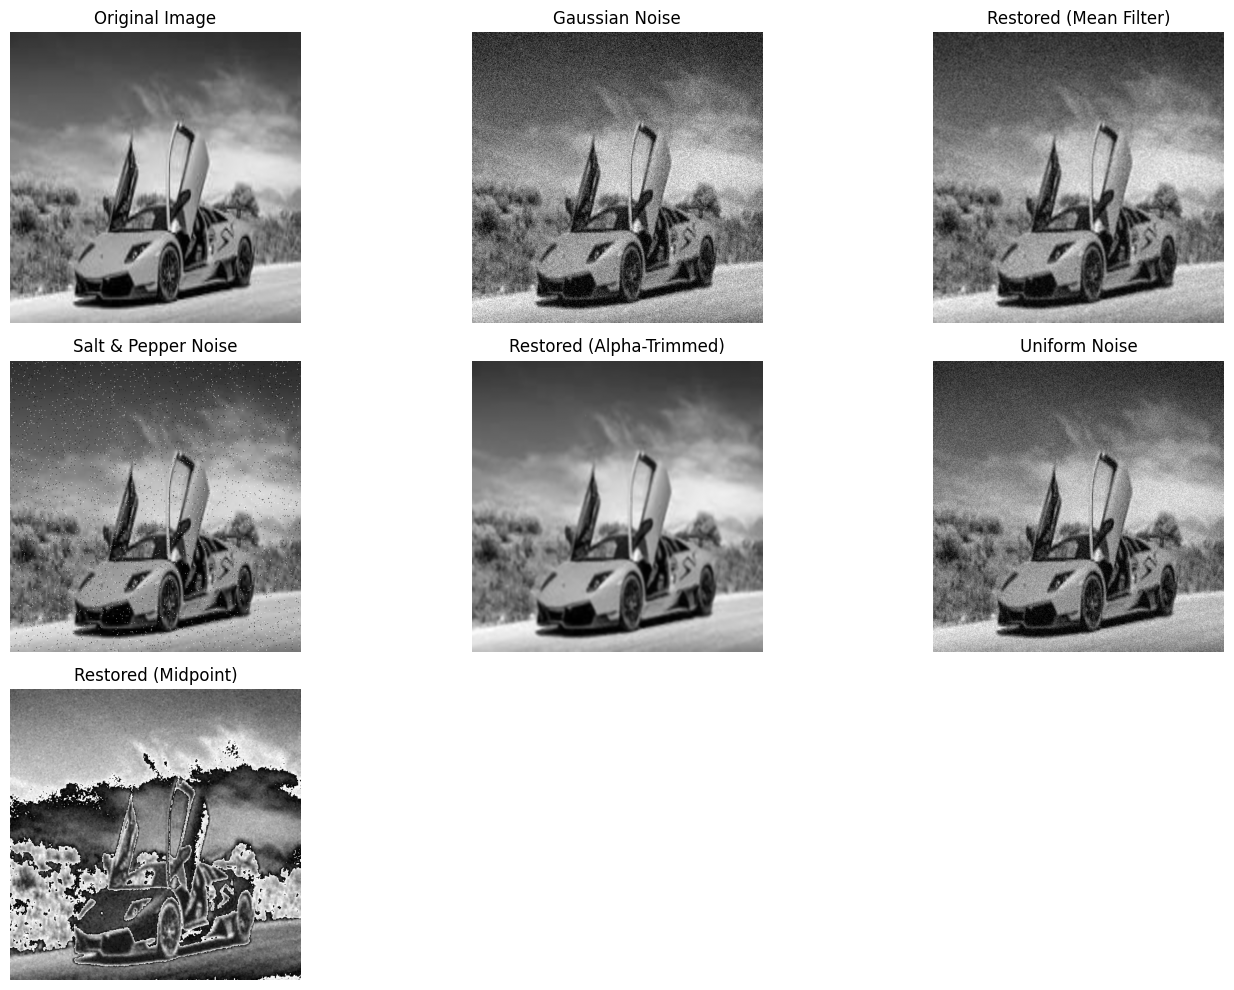

In [ ]:
titles = [
    "Original Image",
    "Gaussian Noise",
    "Restored (Mean Filter)",
    "Salt & Pepper Noise",
    "Restored (Alpha-Trimmed)",
    "Uniform Noise",
    "Restored (Midpoint)"
]

images = [
    image,
    gaussian_noisy,
    restored_gaussian,
    sp_noisy,
    restored_alpha_sp,
    uniform_noisy,
    restored_mid_uniform
]

plt.figure(figsize=(14,10))

for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()
